# Math Score Prediction from Gender — Simple Linear Regression

**Task:** Build a simple (single-variable) linear regression model that predicts `math score` from `gender`, evaluate it, and document the results.


## A) Data Cleaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.precision", 2)

In [2]:
raw = pd.read_csv("../data/StudentsPerformance.csv")
raw.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("Shape:", raw.shape)
print()
print("Missing values (per column):")
print(raw.isna().sum())
print()
print("Fully duplicated rows:", raw.duplicated().sum())

Shape: (1000, 8)

Missing values (per column):
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Fully duplicated rows: 0


In [4]:
print("Column dtypes:")
print(raw.dtypes)

Column dtypes:
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object


Summary: 1000 rows, 8 columns, no missing values, no duplicates. Only `gender` and `math score` are used in this task; `gender` is text, so it's encoded as 0/1 (female=0, male=1).

In [5]:
df = raw[["gender", "math score"]].copy()
df["gender_encoded"] = df["gender"].map({"female": 0, "male": 1})
df.head()

,gender,math score,gender_encoded
0,female,72,0
1,female,69,0
2,female,90,0
3,male,47,1
4,male,76,1


## B) Building the Linear Regression model

In [6]:
X = df[["gender_encoded"]]
y = df["math score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (800, 1)
Test shape:  (200, 1)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m):     {slope:.2f}")
print(f"Intercept (b): {intercept:.2f}")

Slope (m):     4.59
Intercept (b): 64.32


In [8]:
y_pred = model.predict(X_test)

pd.DataFrame({
    "gender_encoded": X_test["gender_encoded"].values,
    "Actual math score": y_test.values,
    "Predicted math score": y_pred,
}).round(2)

,gender_encoded,Actual math score,Predicted math score
0,0,91,64.32
1,0,53,64.32
2,1,80,68.91
3,1,74,68.91
4,1,84,68.91
...,...,...,...
195,0,52,64.32
196,1,62,68.91
197,0,74,64.32
198,0,65,64.32


## C) Measuring model accuracy

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2:  {r2:.4f}")

MAE:  12.05
MSE:  236.59
RMSE: 15.38
R^2:  0.0278


### Bonus: scatter plot + regression line

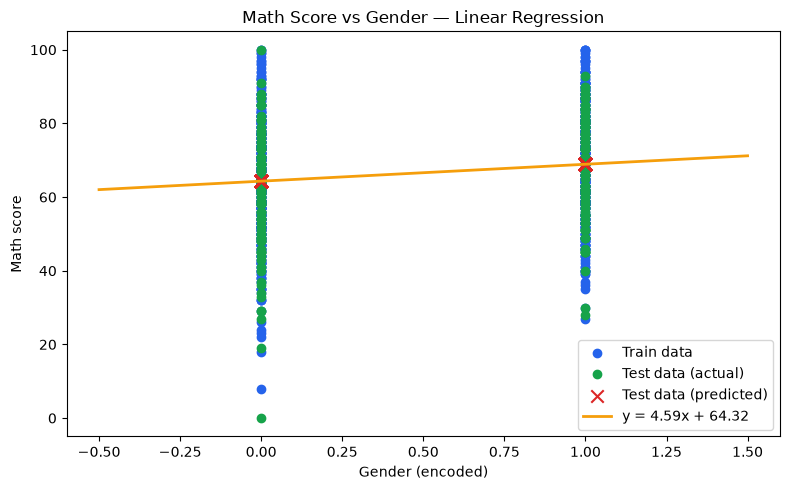

In [10]:
line_x = np.linspace(X["gender_encoded"].min() - 0.5, X["gender_encoded"].max() + 0.5, 50)
line_y = slope * line_x + intercept

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="#2563eb", label="Train data")
plt.scatter(X_test, y_test, color="#16a34a", label="Test data (actual)")
plt.scatter(X_test, y_pred, color="#dc2626", marker="x", s=80, label="Test data (predicted)")
plt.plot(line_x, line_y, color="#f59e0b", linewidth=2, label=f"y = {slope:.2f}x + {intercept:.2f}")
plt.xlabel("Gender (encoded)")
plt.ylabel("Math score")
plt.title("Math Score vs Gender — Linear Regression")
plt.legend()
plt.tight_layout()
plt.savefig("../results/students_gender_math_plot.png", dpi=150)
plt.show()